# Laptop Pricing Predictive Modeling

### 👨‍💻 Executive Summary
This notebook demonstrates the application of Linear and Polynomial Regression to forecast laptop 
market prices. My implementation focuses on feature significance (P-values) to identify the 
primary drivers of hardware cost, transitioning from a baseline Simple Linear Regression 
to a refined Multiple Linear Regression model.

---
*Original lab framework provided by IBM Skills Network. Technical implementation, 
statistical analysis, and model interpretation performed by [Roberto Castro/rcastro-ai](https://github.com/rcastro-ai)*

# Model Development

In this project, we will use the skills acquired in throughout the module, and use linear regression principles to create a model that predicts the Price of the laptop, based on one or more attributes of the dataset.

# Objectives

After completing this project we will be able to:

 - Use Linear Regression in one variable to fit the parameters to a model
 - Use Linear Regression in multiple variables to fit the parameters to a model
 - Use Polynomial Regression in single variable tofit the parameters to a model
 - Create a pipeline for performing linear regression using multiple features in polynomial scaling
 - Evaluate the performance of different forms of regression on basis of MSE and R^2 parameters


# Setup


For this lab, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


The following required libraries are __not__ pre-installed in the Skills Network Labs environment. __You will need to run the following cell__ to install them:


In [1]:
# Installing needed library (for Pyodide environment) - In local Anaconda environment this is already available

#import piplite
#await piplite.install('seaborn')

### Importing Required Libraries

_We recommend you import all required libraries in one place (here):_


In [2]:
# Importing needed libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 
%matplotlib inline

### Importing the dataset
Run the cell below to download the dataset into this environment.

This function will download the dataset into your browser


In [3]:
#This function will download the dataset into your browser (for Pyodide environment)

#from pyodide.http import pyfetch

# Method to download the file

#async def download(url, filename):
#    response = await pyfetch(url)
#    if response.status == 200:
#        with open(filename, "wb") as f:
#            f.write(await response.bytes())

We put the file path along with a quotation mark so that pandas will read the file into a dataframe from that address. The file path can be either an URL or your local file address.


In [4]:
# Variables containing the location of the dataset and the file name

path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"
file_name = "laptops_C7M4.csv"

You will need to download the dataset using the download() function:


In [5]:
# Downloading the dataset (for Pyodide environment)

#await download(path, file_name)

Load the dataset into a pandas dataframe


In [6]:
# When loading from local file after downloading the file (web version)

#df = pd.read_csv(file_name, header=0)

In [7]:
# Using this code for local version (Anaconda, for example)

# Loading data into dataframe
df = pd.read_csv(path, header=0) # Dataset has headers in row 0

# Saving original file locally
df.to_csv(file_name)

>Note: This version of the lab is working on JupyterLite, which requires the dataset to be downloaded to the interface.While working on the downloaded version of this notebook on their local machines(Jupyter Anaconda), the learners can simply skip the steps above, and simply use the URL directly in the pandas.read_csv() function. You can uncomment and run the statements in the cell below.


In [8]:
# Browsing the first 5 rows using dataframe.head() method

print("\nThe first 5 rows of the dataframe:\n") 
df.head(5)


The first 5 rows of the dataframe:



,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,1,1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,2,2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,3,3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,4,4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


# Single Linear Regression

You have learnt that "CPU_frequency" is the parameter with the lowest p-value among the different features of the dataset. Create a single feature Linear Regression model that fits the pair of "CPU_frequency" and "Price" to find the model for prediction.

Starting with a baseline SLR using CPU_frequency, as it demonstrated the highest statistical significance ($p < 0.001$)

In [9]:
# Creating SLR for "CPU_frequency" and "Price"

# Creating the linear regression object
lm = LinearRegression()

# Creating the variables to use in the linear regression
X1 = df[['CPU_frequency']]
Y = df['Price']

# Creating the linear model with X1 and Y
lm.fit(X1, Y)

Yhat1 = lm.predict(X1)

Generate the Distribution plot for the predicted values and that of the actual values. How well did the model perform?


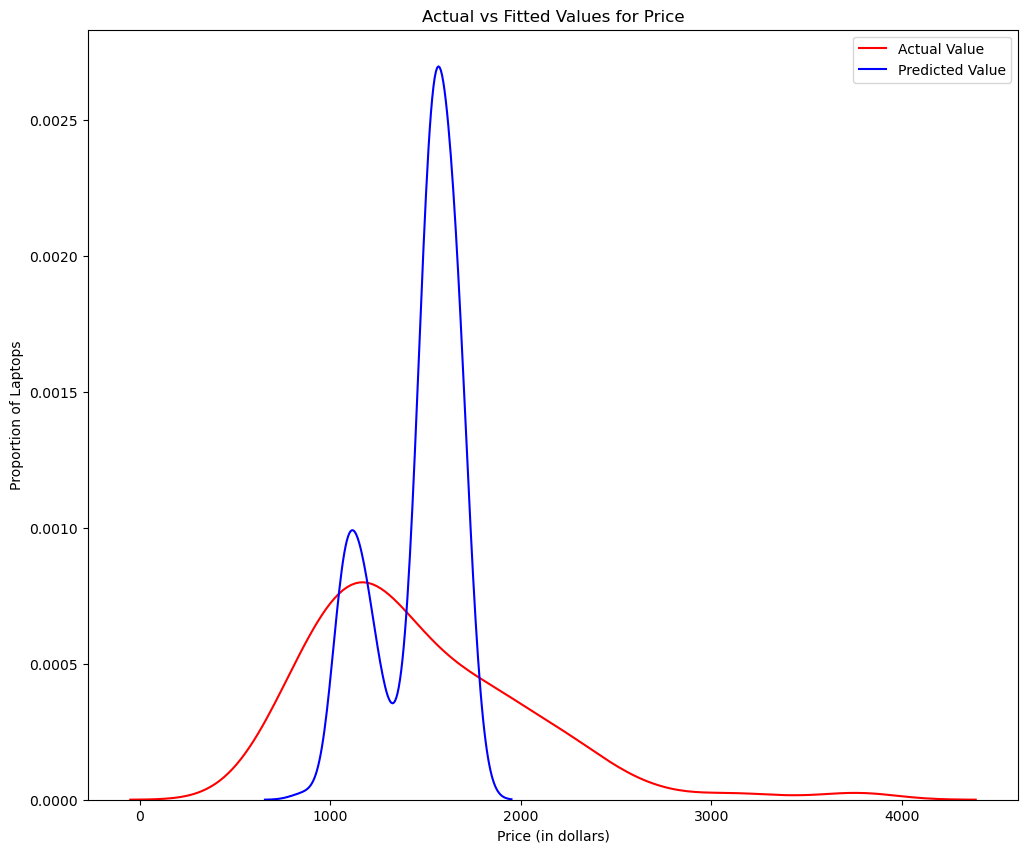

In [10]:
# Plotting the distribution of actual and predicted values

width = 12
height = 10

plt.figure(figsize=(width, height))

ax1 = sns.distplot(df['Price'], hist=False, color="r", label="Actual Values")
sns.distplot(Yhat1, hist=False, color="b", label="Fitted Values" , ax=ax1)

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price (in dollars)')
plt.ylabel('Proportion of Laptops')
plt.legend(['Actual Value', 'Predicted Value'])

plt.show()
plt.close()

Based on the distribution diagram of actual values and predicted values we can see that the model is not performing well. The model is not predicting any prices over 2000 and it also has a similar problem with laptops costing less than 1000.

Evaluate the Mean Squared Error and R^2 score values for the model. 


In [11]:
# Generating the MSE

mse = mean_squared_error(df['Price'], Yhat1)
print('The mean square error of Price and predicted value is: ', mse)

# Generating the R^2
print('The R-square is: ', lm.score(X1, Y))

The mean square error of Price and predicted value is:  284583.4405868629
The R-square is:  0.1344436321024326


# Multiple Linear Regression
The parameters which have a low enough p-value so as to indicate strong relationship with the 'Price' value are 'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU' and 'Category'. Use all these variables to create a Multiple Linear Regression system. 

In [12]:
# Generating a MLR for the laptop model

# Creating the linear regression object
lm1 = LinearRegression()

# Creating dataframe with the predictor (independent) variables
Z = df[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU', 'Category']]

# Fitting the linear model using the dataframe containing the predictor variables and a series containing price (target variable)
lm1.fit(Z, df['Price'])

# Generating predictions
Yhat2 = lm1.predict(Z)

Plot the Distribution graph of the predicted values as well as the Actual values


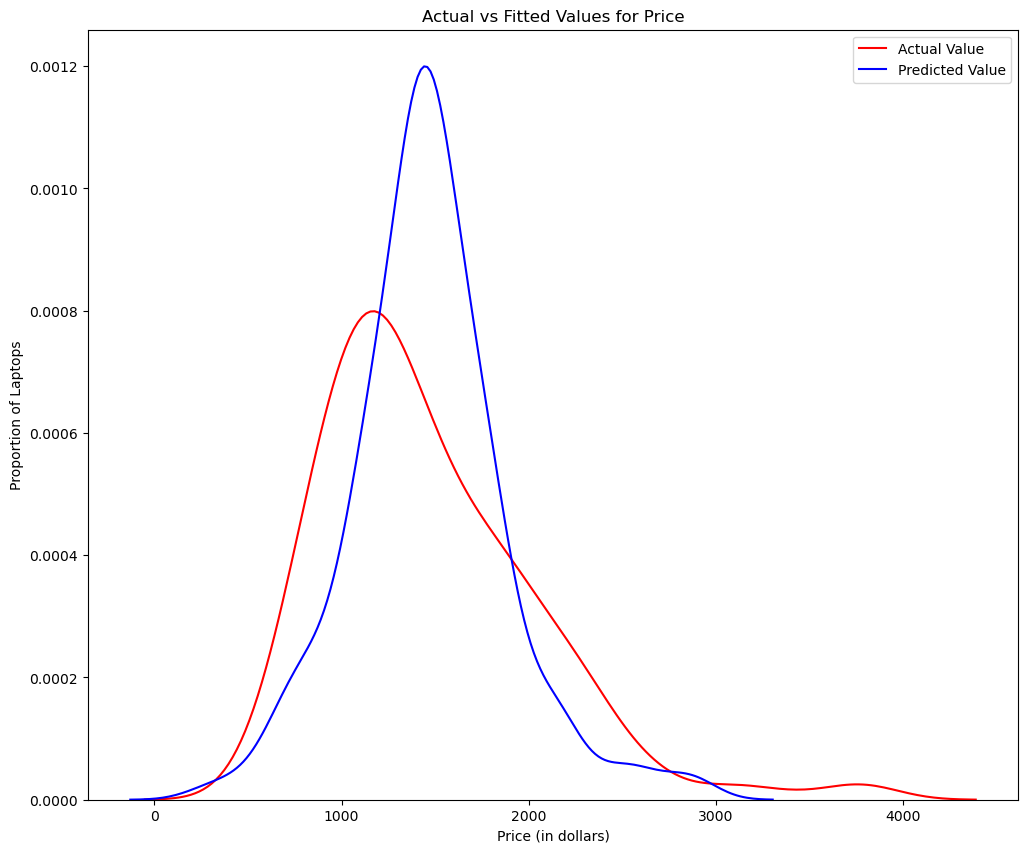

In [13]:
# Plotting the distribution of actual and predicted values

width = 12
height = 10

plt.figure(figsize=(width, height))

ax1 = sns.distplot(df['Price'], hist=False, color="r", label="Actual Values")
sns.distplot(Yhat2, hist=False, color="b", label="Fitted Values" , ax=ax1)

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price (in dollars)')
plt.ylabel('Proportion of Laptops')
plt.legend(['Actual Value', 'Predicted Value'])

plt.show()
plt.close()

Find the R^2 score and the MSE value for this fit. Is this better or worst than the performance of Single Linear Regression?


In [14]:
# Generating the MSE

mse = mean_squared_error(df['Price'], Yhat2)
print('The mean square error of Price and predicted value is: ', mse)

# Generating the R^2
print('The R-square is: ', lm1.score(Z, Y))


The mean square error of Price and predicted value is:  161680.5726389311
The R-square is:  0.5082509055187374


Both MSE and R Squared for the Multiple Linear Regression are better than the ones from the Single Linear Regression. By moving from a single-feature (CPU frequency) to a multi-feature model (CPU frequency, RAM, SSD storage size, CPU core, OS, GPU, and category), the 'Fitted' curve more closely tracks the 'Actual' market price, specifically in the mid-to-high performance tiers.

# Polynomial Regression
Use the variable "CPU_frequency" to create Polynomial features. Try this for 3 different values of polynomial degrees. Remember that polynomial fits are done using `numpy.polyfit`. 

In [15]:
# Defining series

x = df['CPU_frequency']
y = df['Price']

# Using a polynomial of the 1st order (Linear) 
f1 = np.polyfit(x, y, 1)
p1 = np.poly1d(f1)
print(p1)

# Using a polynomial of the 3rd order (Cubic) 
f3 = np.polyfit(x, y, 3)
p3 = np.poly1d(f3)
print(p3)

# Using a polynomial of the 5th order
f5 = np.polyfit(x, y, 5)
p5 = np.poly1d(f5)
print(p5)


 
1485 x + 253.7
           3             2
3.409e+04 x - 6.574e+04 x + 4.129e+04 x - 7238
           5            4             3             2
1.357e+06 x - 4.72e+06 x + 6.458e+06 x - 4.336e+06 x + 1.425e+06 x - 1.818e+05


Plot the regression output against the actual data points to note how the data fits in each case. To plot the polynomial response over the actual data points, you have the function shown below.


In [16]:
def PlotPolly(model, independent_variable, dependent_variabble, Name):
    x_new = np.linspace(independent_variable.min(),independent_variable.max(),100)
    y_new = model(x_new)

    plt.plot(independent_variable, dependent_variabble, '.', x_new, y_new, '-')
    plt.title(f'Polynomial Fit for Price ~ {Name}')
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    fig = plt.gcf()
    plt.xlabel(Name)
    plt.ylabel('Price of Laptops')

Call this function for the 3 models created and get the required graphs.


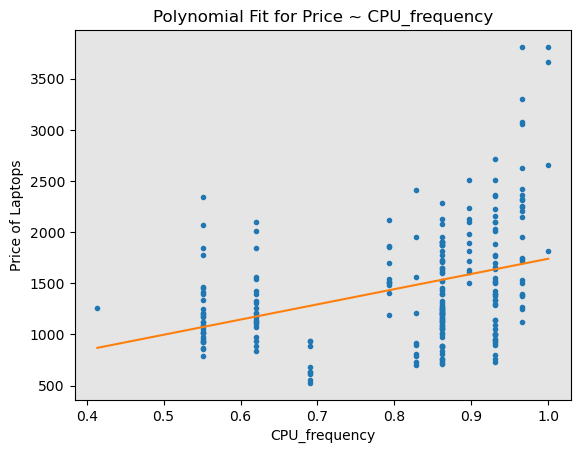

In [17]:
# Plotting the function p1 (degree 1)

PlotPolly(p1, x, y, 'CPU_frequency')

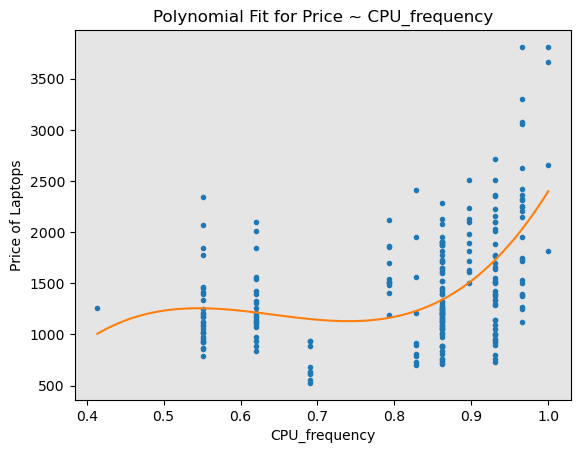

In [18]:
# Plotting the function p3 (degree 3)

PlotPolly(p3, x, y, 'CPU_frequency')


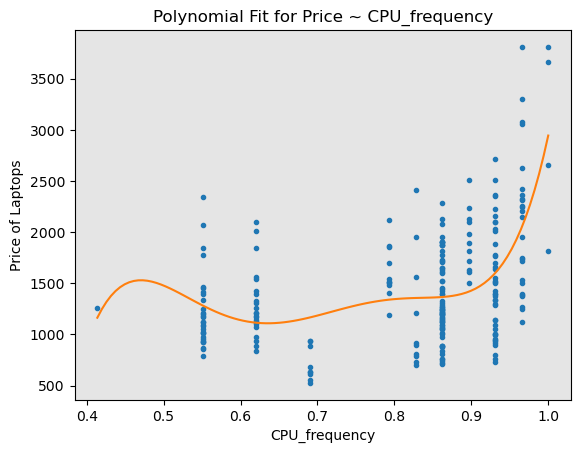

In [19]:
# Plotting the function p5 (degree 5)

PlotPolly(p5, x, y, 'CPU_frequency')


Also, calculate the R^2 and MSE values for these fits. For polynomial functions, the function sklearn.metrics.r2_score will be used to calculate R^2 values.


In [20]:
# MSE and R Square for model p1 (degree 1)

# Generating predicted values for p1
y_1 = p1(x)
# Calculating R Square for p1
r2_1 = r2_score(y, y_1)
# Calculating MSE for p1
mse_1 = mean_squared_error(y, y_1)
# Printing values
print(f'For model of degree 1 MSE is: {mse_1} and R Square is {r2_1}')                   

# MSE and R Square for model p3 (degree 3)

# Generating predicted values for p3
y_3 = p3(x)
# Calculating R Square for p3
r2_3 = r2_score(y, y_3)
# Calculating MSE for p3
mse_3 = mean_squared_error(y, y_3)
# Printing values
print(f'For model of degree 3 MSE is: {mse_3} and R Square is {r2_3}')  

# MSE and R Square for model p (degree 5)

# Generating predicted values for p5
y_5 = p5(x)
# Calculating R Square for p5
r2_5 = r2_score(y, y_5)
# Calculating MSE for p5
mse_5 = mean_squared_error(y, y_5)
# Printing values
print(f'For model of degree 5 MSE is: {mse_5} and R Square is {r2_5}')  

For model of degree 1 MSE is: 284583.4405868629 and R Square is 0.1344436321024326
For model of degree 3 MSE is: 241024.8630384878 and R Square is 0.26692640796531075
For model of degree 5 MSE is: 229137.29548054864 and R Square is 0.3030822706443488


# Pipeline
Create a pipeline that performs parameter scaling, Polynomial Feature generation and Linear regression. Use the set of multiple features as before to create this pipeline. 

In [21]:
# Creating a pipeline that performs parameter scaling, Polynomial Feature generation and Linear regression

# Creating the tuples for the pipeline
Input=[('scale', StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model',LinearRegression())]

# Creating the pipeline
pipe = Pipeline(Input)

# Fitting the model - Using set of multiple features used in Task #2 Z
Z1 = Z.astype(float)
pipe.fit(Z1, y)

# Generating predicted values
Ypipe = pipe.predict(Z1)

Evaluate the MSE and R^2 values for the this predicted output.


In [22]:
# Obtaining MSE and R Square for the predicted output

# Calculating R Square 
r2_p = r2_score(y, Ypipe)
# Calculating MSE 
mse_p = mean_squared_error(y, Ypipe)
# Printing values
print(f'For model created with the pipeline MSE is: {mse_p} and R-squared is {r2_p}')  

For model created with the pipeline MSE is: 120595.86128028372 and R Square is 0.6332094535859658


We now see that the values of R^2 increase as we go from Single Linear Regression to Multiple Linear Regression. Further, if we go for multiple linear regression extended with polynomial features, we get an even better R^2 value.

---

### Original Lab Author(s)

[Abhishek Gagneja](https://www.coursera.org/instructor/~129186572)

[Vicky Kuo](https://author.skills.network/instructors/vicky_kuo)

Copyright ©IBM Corporation. All rights reserved.